# Radio Modulation with FINN - Notebook #5 of 5

## FPGA setup 
**NOTE**: This notebook is meant to be run on the FPGA. After running the previous notebook, this notebook should be copied to the output directory along with the bitfile and driver files.

Make sure you have setup the FPGA with the PYNQ os correctly installed. 

To copy this notebook from you HOST machine to the FPGA and run ***on the fpga*** (substitute IP with the IP of the FPGA device)
1. `scp -r deploy xilinx@IP:/home/xilinx`
2. `ssh -L 8888:localhost:8888 xilinx@IP`
3. `sudo -E jupyter notebook --port 8888 --allow-root` 
4. Click the URL generated by jupyter notebook to enter jupyter and select this script. 

## Overview

This notebook walks you through how you can run benchmark and verification on the FPGA based on the bitstream and driver generated by FINN.

Overview of the generated files:
- `driver.py`: Description of the FINN-generated accelerator, including the input/output shapes and datatype.<br><br>
- `driver_base.py`: A class designed for FINN dataflow accelerator. This includes many functions such as instantiating the accelerator, running benchmark on an empty input, setting batchsize, executing inputs, ...<br><br>
- `validate.py`: An example validation python script to test run image regconition CNN accelerator. This `validate.py` file is irrelevant to our project, but it gives us a good example on how to instantiate and run validation on accelerator. Instead, we will use this notebook as a replacement for running benchmark and validation.<br><br>
- `[model_name].bit`: The generated Bitfile from synthesis depending on the target platform.<br><br>
- `[model_name].hwh`: The generated Hardware Handoff File<br><br>

### **TODO**: more documentation on data preprocesssing. Though since our case is special, where the input is already quantized to 8 bits. We may be able to remove it. However, incase we want to quantize the model down to 4bits, then we need the preprocessing back.

# Initialize the accelerator

The accelerator is Neural Network, but FPGA-ified! Specifically, the accelerator is simply a python wrapper around the bitstream we generated in the previous steps. This allows use to then treat the accelerator object as our model to achieve high performancer (higher than cpu) modulation classification by using the FPGA design! 

### Remember to install the following dependencies:

In [1]:
# ! apt-get update -y
# ! apt-get install libhdf5-dev -y
# ! pip3 install versioned-hdf5

In [4]:
!export XILINX_XRT=/usr

from finn_examples import models
# Note: the RadioML example is only available on the ZCU104 at the moment
import pynq
from pynq import PL
from driver import io_shape_dict
from driver_base import FINNExampleOverlay
import numpy as np
import math
import pickle
import os
import h5py
from pathlib import Path

PL.reset() #Ensure pynq clear cached hwh

In [5]:
accel=  FINNExampleOverlay(
        bitfile_name="./finn-accel.bit",#change this to your bitfile name
        platform="zynq-iodma",
        io_shape_dict=io_shape_dict,
        batch_size=1,
        runtime_weight_dir="runtime_weights/",
        fclk_mhz=310.0
    )   

/usr/local/share/pynq-venv/lib/python3.10/site-packages/pynq/ps.py:434: UserWarning: Setting frequency to the closest possible value 299.997MHz.
  warnings.warn(


In [6]:
print("Expected input shape and datatype: %s %s" % (str(accel.ishape_normal()), str(accel.idt())))
print("Expected output shape and datatype: %s %s" % (str(accel.oshape_normal()), str(accel.odt())))

Expected input shape and datatype: (1, 1024, 1, 2) INT8
Expected output shape and datatype: (1, 1) UINT8


# Load RadioML 2021 dataset

In [ ]:
#Change this to your dataset directory
dataset = Path("./MatGenData_ppm0_rician_int8_20251006.h5")
model_bit_width=8
assert dataset.is_file()
print(dataset)

MatGenData_ppm0_rician_int8_20251006.h5


In [8]:
h5_file = h5py.File(dataset,'r')
data_key='all_IQ_8bit'
mod_key='all_labels'
snr_key='all_SNRs'

print("Extracting INT8 Matlab Generated Data....")
data_h5 = h5_file[data_key]

print("Get labels")
label_mod = h5_file[mod_key][:,0] # comes in one-hot encoding


print("Get SNR")
label_snr = h5_file[snr_key][:,0]

# assemble list of test set indices
# do not pre-load large dataset into memory
np.random.seed(2021)
test_indices = []
mod_classes = ["BPSK", 
                "QPSK", 
                "8PSK",
                "16QAM",
                "32QAM", 
                "64QAM", 
                "128QAM", 
                "256QAM",
                "16APSK", 
                "32APSK", 
                "64APSK", 
                "128APSK",
                "FM", 
                "AM-DSB-SC", 
                "AM-SSB-SC"]
snr_classes = np.arange(0.0, 32., 2) # 0dB to 30dB

for mod in range(0, len(mod_classes)): #all modulations (0 to 26)
    for snr_idx in range(0,len(snr_classes)): #all SNRs (0 to 25 = -20dB to +30dB)
        start_idx = len(snr_classes)*4096*mod + 4096*snr_idx
        indices_subclass = list(range(start_idx, start_idx+4096))

        split = int(np.ceil(0.1 * 4096)) #90%/10% split
        np.random.shuffle(indices_subclass)
        train_indices_subclass, val_indices_subclass = indices_subclass[split:], indices_subclass[:split]

        if snr_idx >= 0: #select which SNRs to test on 
            test_indices.extend(val_indices_subclass)

test_indices = sorted(test_indices)

Extracting INT8 Matlab Generated Data....
Get labels
Get SNR


In [9]:
print(data_h5.shape)
print(label_mod.shape)
print(label_snr.shape)
print(len(test_indices))

(983040, 1024, 2)
(983040,)
(983040,)
98400


# Inspect a single frame

Modulation: AM-SSB-SC, SNR: 26.0 dB


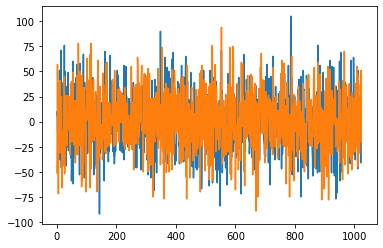

In [12]:
%matplotlib inline
from matplotlib import pyplot as plt

# Inspect a frame
mod = 14 
snr_idx = 13 
sample = 123 # 0 to 4095
#-----------------------#
idx = len(snr_classes)*4096*mod + 4096*snr_idx + sample
data, mod, snr = data_h5[idx], label_mod[idx], label_snr[idx]
plt.figure()
plt.plot(data)
print("Modulation: %s, SNR: %.1f dB" % (mod_classes[mod], snr))

# Input quantization
Quantize input data on-the-fly in software before feeding it to the accelerator. Use the uniform quantization range on which the model was trained.

In [ ]:
# raw_dataset_bit_width=8
# model_bit_width=4

# raw_dataset_min=- (2.0**(raw_dataset_bit_width-1))
# raw_dataset_max=-raw_dataset_min-1
# raw_dataset_range=abs(raw_dataset_max-raw_dataset_min)+1

# new_min=-(2.0**(model_bit_width-1))
# new_max=-new_min-1
# new_range=abs(new_max-new_min)+1

# print(raw_dataset_min,' ',raw_dataset_max,' ',raw_dataset_range)
# print(new_min,' ',new_max,' ',new_range)
# def quantize(data):
#     normalized_data=(data-raw_dataset_min)/raw_dataset_range
#     scaled_data=np.round(normalized_data*new_range)+new_min
#     data_quant=np.clip(scaled_data,new_min,new_max)
#     # data_quant=data
#     data_quant = data_quant.astype(np.int8)
#     return data_quant

def quantize(data):
    return data.astype(np.int8)

# Classify a single frame

In [14]:
accel_in = quantize(data).reshape(accel.ishape_normal())
print("Input buffer shape is %s and datatype is %s" % (str(accel_in.shape), str(accel_in.dtype)))

Input buffer shape is (1, 1024, 1, 2) and datatype is int8


In [15]:
accel_out = accel.execute(accel_in)

In [16]:
print("Result: " + str(accel_out))
print("Top-1 class predicted by the accelerator: " + mod_classes[int(accel_out)])

Result: [[13.]]
Top-1 class predicted by the accelerator: AM-DSB-SC


In [17]:
%%timeit
accel_out = accel.execute(accel_in)

1.39 ms ± 10.4 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


# Validate accuracy on entire test set

In [18]:
batch_size = 1024
accel.batch_size = batch_size
print("Accelerator buffer shapes are %s for input, %s for output" % (str(accel.ishape_packed()), str(accel.oshape_packed())))
print("Accelerator buffer shapes are %s for input, %s for output" % (str(accel.ishape_folded()), str(accel.oshape_folded())))
print("Accelerator buffer shapes are %s for input, %s for output" % (str(accel.ishape_normal()), str(accel.oshape_normal())))

Accelerator buffer shapes are (1024, 1024, 1, 1, 2) for input, (1024, 1, 1) for output
Accelerator buffer shapes are (1024, 1024, 1, 1, 2) for input, (1024, 1, 1) for output
Accelerator buffer shapes are (1024, 1024, 1, 2) for input, (1024, 1) for output


In [19]:
import time
ok = 0
nok = 0
total = len(test_indices)
timer=0

y_exp = np.empty((0))
y_snr = np.empty((0))
y_pred = np.empty((0,len(mod_classes)))

for i_batch in range(math.ceil(total/batch_size)):
    i_frame = i_batch*batch_size
    if i_frame+batch_size > total:
        batch_size = total - i_frame
        accel.batch_size = batch_size
    batch_indices = test_indices[i_frame:i_frame+batch_size]
    data, mod, snr = data_h5[batch_indices], label_mod[batch_indices], label_snr[batch_indices]
    
    
    ibuf = quantize(data).reshape(accel.ishape_normal())
    
    start_time=time.time()
    obuf = accel.execute(ibuf)
    batch_time=time.time()-start_time
    timer+=batch_time
    
    pred = obuf.reshape(batch_size).astype(int)

    ok += np.equal(pred, mod).sum().item()
    nok += np.not_equal(pred, mod).sum().item()
    
    print("batch %d / %d : total OK %d | NOK %d | Time: %.2f seconds" % (i_batch,math.ceil(total/batch_size), ok, nok, batch_time))
    
    y_exp = np.concatenate((y_exp, mod))
    y_snr = np.concatenate((y_snr, snr))
    
    # Convert predicted index to one-hot
    one_hot = np.zeros((batch_size, len(mod_classes)))
    one_hot[np.arange(batch_size), pred] = 1
    y_pred = np.vstack((y_pred, one_hot))
    
print('total time: ',timer,' seconds')

batch 0 / 97 : total OK 877 | NOK 147 | Time: 0.35 seconds
batch 1 / 97 : total OK 1880 | NOK 168 | Time: 0.35 seconds
batch 2 / 97 : total OK 2901 | NOK 171 | Time: 0.35 seconds
batch 3 / 97 : total OK 3925 | NOK 171 | Time: 0.35 seconds
batch 4 / 97 : total OK 4949 | NOK 171 | Time: 0.36 seconds
batch 5 / 97 : total OK 5973 | NOK 171 | Time: 0.35 seconds
batch 6 / 97 : total OK 6492 | NOK 676 | Time: 0.35 seconds
batch 7 / 97 : total OK 6931 | NOK 1261 | Time: 0.35 seconds
batch 8 / 97 : total OK 7695 | NOK 1521 | Time: 0.35 seconds
batch 9 / 97 : total OK 8603 | NOK 1637 | Time: 0.35 seconds
batch 10 / 97 : total OK 9577 | NOK 1687 | Time: 0.35 seconds
batch 11 / 97 : total OK 10567 | NOK 1721 | Time: 0.35 seconds
batch 12 / 97 : total OK 11397 | NOK 1915 | Time: 0.35 seconds
batch 13 / 97 : total OK 11561 | NOK 2775 | Time: 0.35 seconds
batch 14 / 97 : total OK 11992 | NOK 3368 | Time: 0.35 seconds
batch 15 / 97 : total OK 12715 | NOK 3669 | Time: 0.35 seconds
batch 16 / 97 : total

In [20]:
accuracy = 100.0 * ok / (total)
print("Overall top-1 accuracy: {}%".format(accuracy))

Overall top-1 accuracy: 59.71544715447155%


## More benchmarking

In [21]:
accel.batch_size = 1024
accel.throughput_test()

{'runtime[ms]': 350.2829074859619,
 'throughput[images/s]': 2923.3513200784378,
 'DRAM_in_bandwidth[MB/s]': 5.98702350352064,
 'DRAM_out_bandwidth[MB/s]': 0.0029233513200784375,
 'fclk[mhz]': 299.997,
 'batch_size': 1024,
 'fold_input[ms]': 0.09202957153320312,
 'pack_input[ms]': 0.06890296936035156,
 'copy_input_data_to_device[ms]': 2.5358200073242188,
 'copy_output_data_from_device[ms]': 0.1266002655029297,
 'unpack_output[ms]': 0.5128383636474609,
 'unfold_output[ms]': 0.06365776062011719}

Overall Accuracy across all SNRs: 59.72%


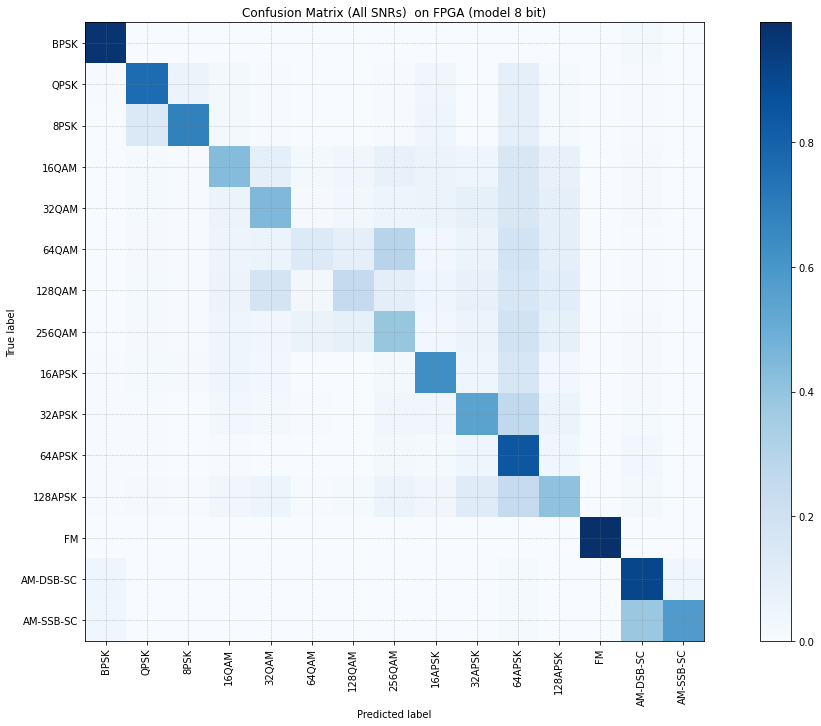

In [24]:
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path

Path("./report").mkdir(exist_ok=True)
# Compute confusion matrix
conf = np.zeros([len(mod_classes), len(mod_classes)])
confnorm = np.zeros([len(mod_classes), len(mod_classes)])

for i in range(len(y_exp)):
    true_label = int(y_exp[i])
    pred_label = int(np.argmax(y_pred[i]))
    conf[true_label, pred_label] += 1

# Normalize rows (i.e., divide each row by the total in that row)
for i in range(len(mod_classes)):
    if np.sum(conf[i, :]) > 0:
        confnorm[i, :] = conf[i, :] / np.sum(conf[i, :])

# Plot confusion matrix
def plot_confusion_matrix(cm, title=f'Confusion Matrix (All SNRs)  on FPGA (model {model_bit_width} bit)', cmap=plt.cm.Blues, labels=[]):
    plt.figure(figsize=(16,10),facecolor='white')
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=90)
    plt.yticks(tick_marks, labels)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.grid(visible=True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.savefig(f'./report/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')
plot_confusion_matrix(confnorm, labels=mod_classes)

# Compute overall accuracy again (for consistency)
correct = np.sum(np.diag(conf))
total = np.sum(conf)
print("Overall Accuracy across all SNRs: {:.2f}%".format(100.0 * correct / total))

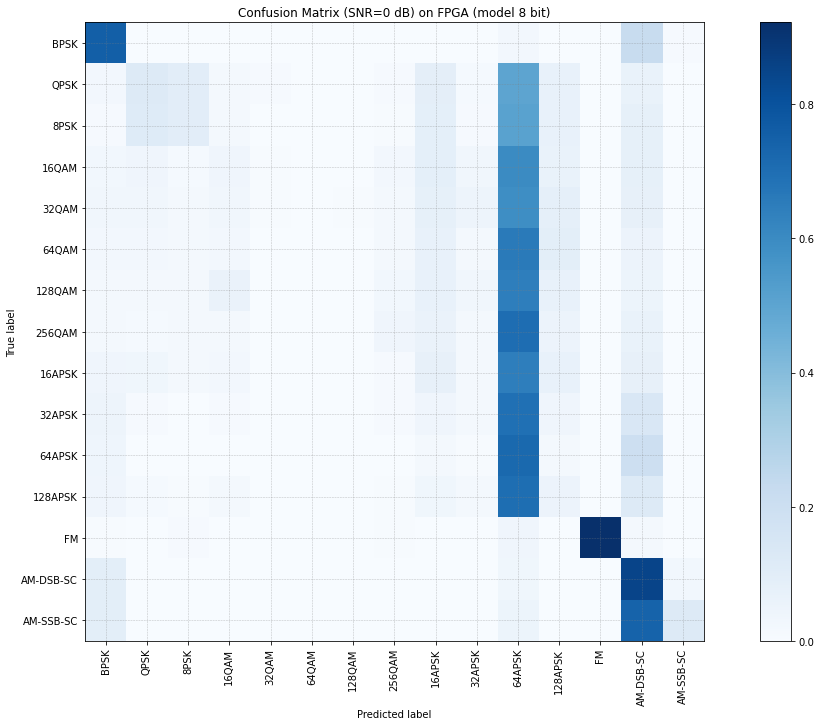

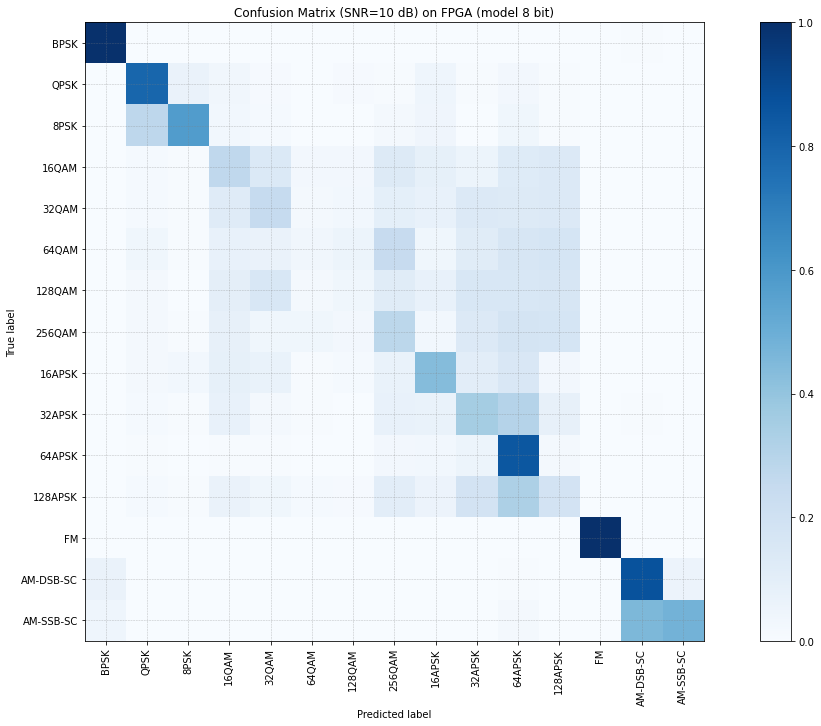

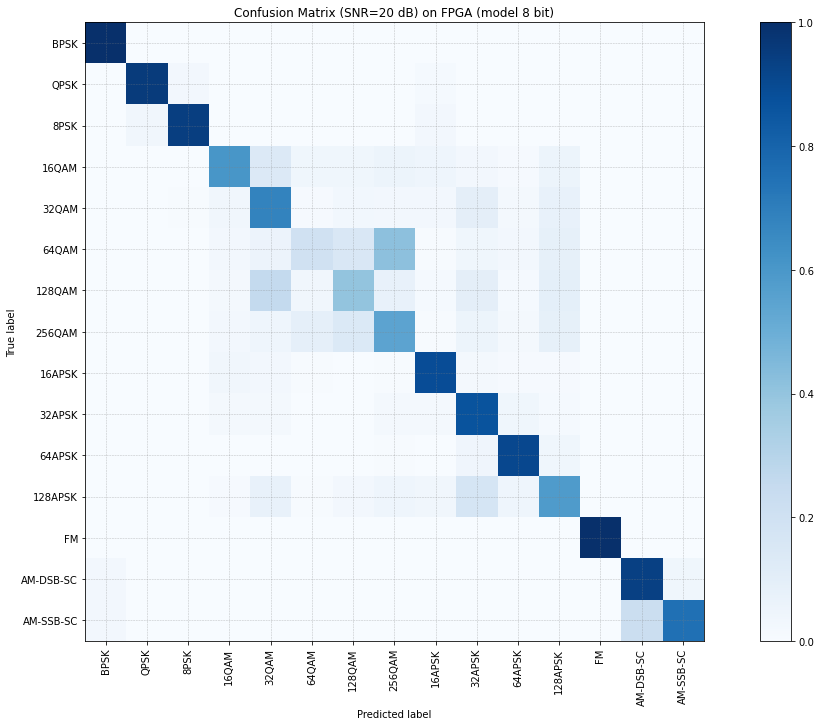

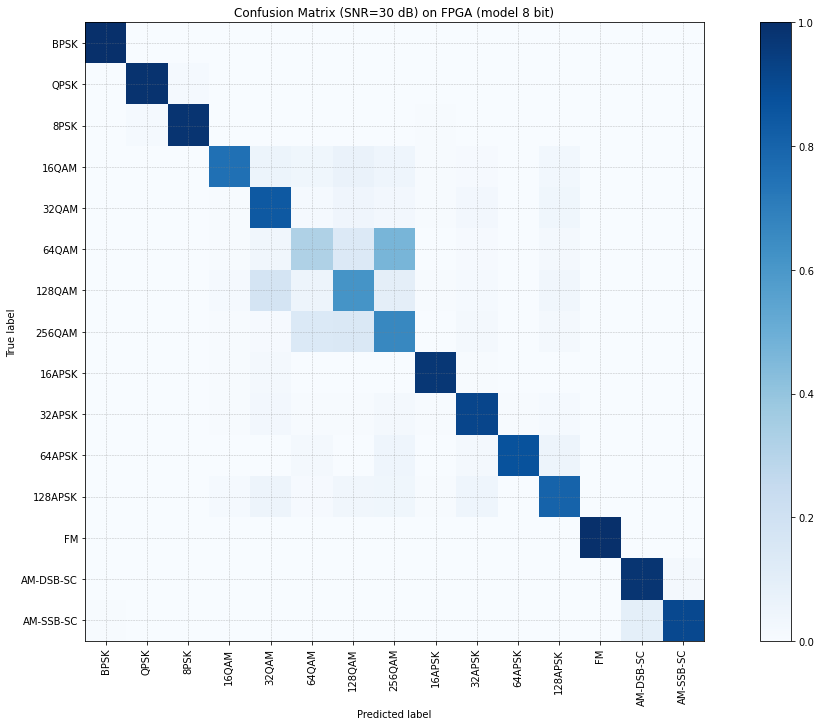

In [25]:
# Loop over SNRs
SNRs_to_plot=[0.0,10.0,20.0,30.0]
unique_snrs = np.unique(y_snr)
acc = []
for snr in unique_snrs:
    indices = np.where(y_snr == snr)[0]
    if len(indices) == 0:
        continue

    conf = np.zeros([len(mod_classes), len(mod_classes)])
    confnorm = np.zeros([len(mod_classes), len(mod_classes)])

    for i in indices:
        true_label = int(y_exp[i])
        pred_label = int(np.argmax(y_pred[i]))
        conf[true_label, pred_label] += 1

    for i in range(len(mod_classes)):
        if np.sum(conf[i, :]) > 0:
            confnorm[i, :] = conf[i, :] / np.sum(conf[i, :])

    if snr in SNRs_to_plot:
        plot_confusion_matrix(confnorm, title=f'Confusion Matrix (SNR={int(snr)} dB) on FPGA (model {model_bit_width} bit)', labels=mod_classes)

    correct = np.sum(np.diag(conf))
    total = np.sum(conf)
    acc.append(correct/(total))
    # print(f"SNR {int(snr)} dB - Accuracy: {100.0 * correct / total:.2f}%")

Accuracy @ highest SNR (30.0 dB): 0.840000
Accuracy @ >= SNR (6.0dB): 0.666091
Accuracy overall: 0.597154
SNR [0.0]: 0.25398373983739836
SNR [2.0]: 0.30113821138211383
SNR [4.0]: 0.34016260162601625
SNR [6.0]: 0.3853658536585366
SNR [8.0]: 0.43040650406504066
SNR [10.0]: 0.49333333333333335
SNR [12.0]: 0.54
SNR [14.0]: 0.6042276422764228
SNR [16.0]: 0.6682926829268293
SNR [18.0]: 0.7092682926829268
SNR [20.0]: 0.7500813008130082
SNR [22.0]: 0.7884552845528455
SNR [24.0]: 0.7998373983739837
SNR [26.0]: 0.8180487804878048
SNR [28.0]: 0.831869918699187
SNR [30.0]: 0.84


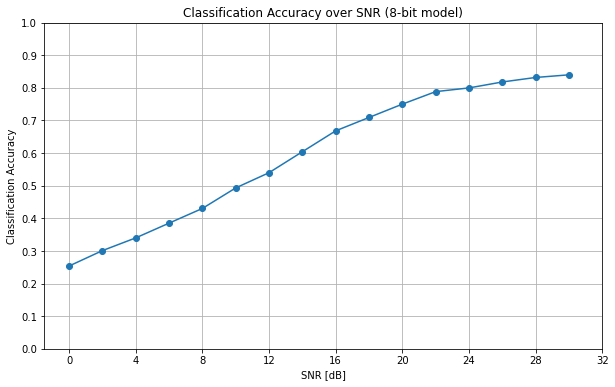

In [26]:
# Plot accuracy over SNR
plt.figure(figsize=(10,6),facecolor='white')
plt.plot(np.arange(0.0, 30.0+2.0, 2.0), acc, marker='o')
plt.xlabel("SNR [dB]")
plt.xticks(np.arange(0.0, 30.0+4.0, 4.0))
plt.ylabel("Classification Accuracy")
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid()
# plt.title("Classification Accuracy over SNR");

title=f"Classification Accuracy over SNR ({model_bit_width}-bit model)"
plt.title(title)
plt.savefig(f'./report/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')

print(f"Accuracy @ highest SNR ({30.0} dB): %f"%(acc[-1]))
print(f"Accuracy @ >= SNR (6.0dB): %f"%(np.average(acc[3:])))
print("Accuracy overall: %f"%(np.mean(acc)))
for i, a in enumerate(acc):
    print(f"SNR [{0.0 + 2*i}]: {a}")

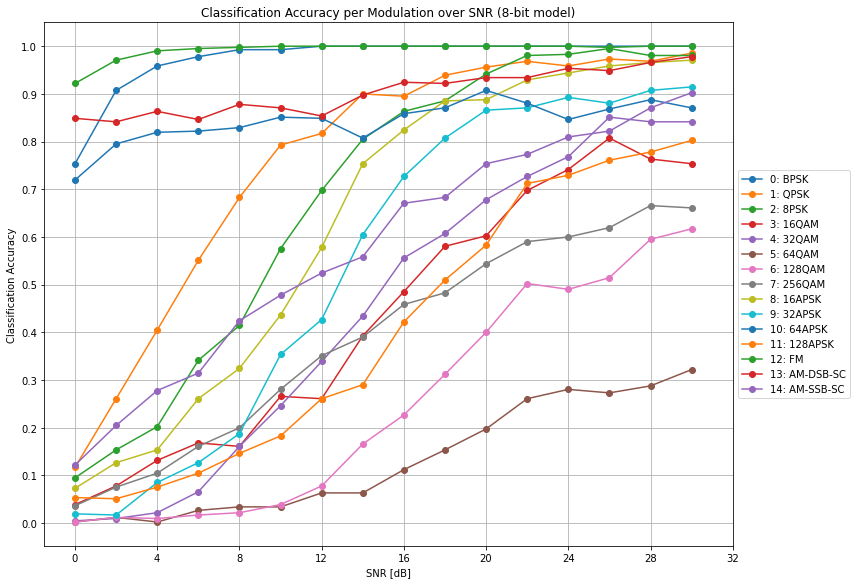

In [27]:
accs = []  # List of lists: one per modulation

# Loop over each modulation class
for mod in range(len(mod_classes)):
    accs_mod = []
    for snr in snr_classes:  
        indices = np.where((y_exp == mod) & (y_snr == snr))[0]
        if len(indices) == 0:
            acc = np.nan  # Avoid divide-by-zero
        else:
            y_true_i = y_exp[indices]
            y_pred_i = y_pred[indices]
            acc = np.mean(y_true_i == np.argmax(y_pred_i, axis=1))
        accs_mod.append(acc)
    accs.append(accs_mod)


# Plot accuracy per modulation over SNR
plt.figure(figsize=(12, 8),facecolor='white')

snr_values = np.arange(0.0, 32.0 , 2.0)  

for mod in range(len(mod_classes)):
    acc_curve = accs[mod]
    label = f"{mod}: {mod_classes[mod]}"
    plt.plot(snr_values, acc_curve, marker='None', label=label)

plt.xlabel("SNR [dB]")
plt.xticks(np.arange(0.0, 30.0 + 4.0, 4.0))
plt.ylabel("Classification Accuracy")
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True)
plt.legend(bbox_to_anchor=(0.825, 0.51),   # position legend outside the right edge
    # loc='upper left',           # anchor point of the legend box
    borderaxespad=0.)
plt.tight_layout()

title=f"Classification Accuracy per Modulation over SNR ({model_bit_width}-bit model)"
plt.title(title)
plt.savefig(f'./report/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')

plt.show()
